<a href="https://colab.research.google.com/github/nindy999/MachineLearning/blob/main/TUGAS_ML_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

1. DATA UNDERSTANDING

In [ ]:
# Load dataset

df = pd.read_excel('mhs_lulusan_clean.csv.xlsx')

print("Jumlah data:", df.shape)
df.head()

Jumlah data: (4553, 20)


,prodi,predikat,tanggal_lulus,tanggal_masuk,jenis_kelamin,tahun_lahir,status_pegawai,ips_1,ips_2,ips_3,ips_4,ips_5,ips_6,ips_7,ips_8,sks_mk,lama_studi,lulus_tepat_waktu,angkatan,lulus_umur
0,Teknik Industri,Pujian,2019-08-31,2015-09-06,Laki-laki,1994,Bekerja,3.223333,3.431429,2.947778,2.90875,3.334444,3.37625,3.428571,3.50,146.0,3.0,Tepat waktu,2015,25
1,Teknik Industri,Pujian,2019-08-31,2015-09-06,Perempuan,1996,Bekerja,3.305556,3.430000,3.111111,3.34375,3.557778,3.47000,3.642857,3.75,146.0,3.0,Tepat waktu,2015,23
2,Teknik Industri,Pujian,2019-08-31,2015-09-06,Laki-laki,1984,Bekerja,3.225556,3.324286,2.946667,3.22000,3.306667,3.03625,3.607143,3.75,146.0,3.0,Tepat waktu,2015,35
3,Teknik Industri,Pujian,2019-08-31,2015-09-06,Laki-laki,1996,Bekerja,3.334444,3.288571,3.224444,3.44000,3.224444,2.69000,3.572857,3.50,146.0,3.0,Tepat waktu,2015,23
4,Teknik Industri,Pujian,2019-08-31,2015-09-06,Laki-laki,1994,Bekerja,3.142222,3.394286,3.000000,3.25000,3.335556,3.15875,3.642857,3.50,146.0,3.0,Tepat waktu,2015,25


In [ ]:
# Statistik data numerik

df.describe()

,tanggal_lulus,tanggal_masuk,tahun_lahir,ips_1,ips_2,ips_3,ips_4,ips_5,ips_6,ips_7,ips_8,sks_mk,lama_studi,angkatan,lulus_umur
count,4553,4553,4553.000000,4553.000000,4552.000000,4553.000000,4553.000000,4553.000000,4553.000000,4553.000000,4553.000000,4553.000000,4553.000000,4553.000000,4553.000000
mean,2022-02-16 17:50:16.472655360,2017-11-13 12:10:16.736218112,1997.368329,3.451091,3.451434,3.497945,3.501558,3.547379,3.578614,3.667178,3.833581,145.899407,3.554711,2016.306172,24.160773
min,2006-12-05 00:00:00,2009-08-06 00:00:00,1959.000000,1.880000,1.880000,2.110000,2.277778,2.252500,2.110000,2.556667,2.000000,120.000000,1.000000,24.000000,19.000000
25%,2020-12-28 00:00:00,2016-09-11 00:00:00,1996.000000,3.252500,3.251250,3.285714,3.288571,3.376250,3.407500,3.535714,3.750000,145.000000,3.000000,2016.000000,22.000000
50%,2022-07-07 00:00:00,2017-09-10 00:00:00,1998.000000,3.472222,3.500000,3.535714,3.562500,3.625000,3.625000,3.714286,4.000000,146.000000,3.000000,2017.000000,23.000000
75%,2023-06-23 00:00:00,2018-09-03 00:00:00,2000.000000,3.666667,3.714286,3.750000,3.750000,3.781250,3.800000,3.857143,4.000000,147.000000,4.000000,2018.000000,25.000000
max,2029-03-15 00:00:00,2026-04-02 00:00:00,2007.000000,4.000000,4.000000,4.000000,4.000000,4.680000,4.000000,4.000000,4.000000,156.000000,7.000000,2025.000000,64.000000
std,NaN,NaN,3.875856,0.285653,0.322074,0.311982,0.321844,0.303501,0.284569,0.241541,0.240339,1.566758,0.776718,41.798515,3.497373


2. DATA PREPROCESSING

In [ ]:
# Membersihkan data

df = df.dropna().drop_duplicates()

print("Data setelah cleaning:", df.shape)

Data setelah cleaning: (4552, 20)


In [ ]:
# Menentukan target dan fitur

target = 'lama_studi'

X = df.drop(target, axis=1)
y = df[target]

In [ ]:
# 3. Label Encoding (Mencegah fitur pecah jadi banyak)
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # Mengubah teks menjadi angka dalam SATU kolom yang sama
    df[col] = le.fit_transform(df[col].astype(str))

# 4. Verifikasi Jumlah Fitur
print(f"Jumlah kolom saat ini: {len(df.columns)}")
print("Daftar kolom:", df.columns.tolist())

Jumlah kolom saat ini: 20
Daftar kolom: ['prodi', 'predikat', 'tanggal_lulus', 'tanggal_masuk', 'jenis_kelamin', 'tahun_lahir', 'status_pegawai', 'ips_1', 'ips_2', 'ips_3', 'ips_4', 'ips_5', 'ips_6', 'ips_7', 'ips_8', 'sks_mk', 'lama_studi', 'lulus_tepat_waktu', 'angkatan', 'lulus_umur']


In [ ]:
# 1. Pastikan data sudah bersih dari missing value
df_clean = df.copy()

# 2. Identifikasi kolom kategori (teks)
categorical_cols = df_clean.select_dtypes(include=['object']).columns

# 3. Ubah teks menjadi angka (Label Encoding)
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 4. Sekarang hitung korelasi (Error ValueError akan hilang)
target = 'lama_studi'
corr = df_clean.corr()[target].abs().sort_values(ascending=False)

# 5. Seleksi fitur yang korelasinya di atas 0.1
selected_features = corr[corr >= 0.1].index.drop(target)
print("Fitur yang terpilih berdasarkan korelasi:")
print(selected_features)

Fitur yang terpilih berdasarkan korelasi:
Index(['lulus_tepat_waktu', 'predikat', 'ips_7', 'ips_2', 'tanggal_masuk',
       'ips_4', 'lulus_umur', 'ips_3', 'ips_1', 'tanggal_lulus', 'ips_8',
       'ips_6', 'jenis_kelamin', 'tahun_lahir'],
      dtype='object')


In [ ]:
# Copy dataset agar data asli tetap aman
df_model = df.copy()

# Mencari semua kolom yang bertipe 'object' (teks)
categorical_cols = df_model.select_dtypes(include=['object']).columns

# Mengubah semua teks menjadi angka
le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Sekarang cek, tidak boleh ada kolom 'object' lagi
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4552 entries, 0 to 4552
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   prodi              4552 non-null   int64         
 1   predikat           4552 non-null   int64         
 2   tanggal_lulus      4552 non-null   datetime64[ns]
 3   tanggal_masuk      4552 non-null   datetime64[ns]
 4   jenis_kelamin      4552 non-null   int64         
 5   tahun_lahir        4552 non-null   int64         
 6   status_pegawai     4552 non-null   int64         
 7   ips_1              4552 non-null   float64       
 8   ips_2              4552 non-null   float64       
 9   ips_3              4552 non-null   float64       
 10  ips_4              4552 non-null   float64       
 11  ips_5              4552 non-null   float64       
 12  ips_6              4552 non-null   float64       
 13  ips_7              4552 non-null   float64       
 14  ips_8        

3. Exploratory Data Analysis (EDA)

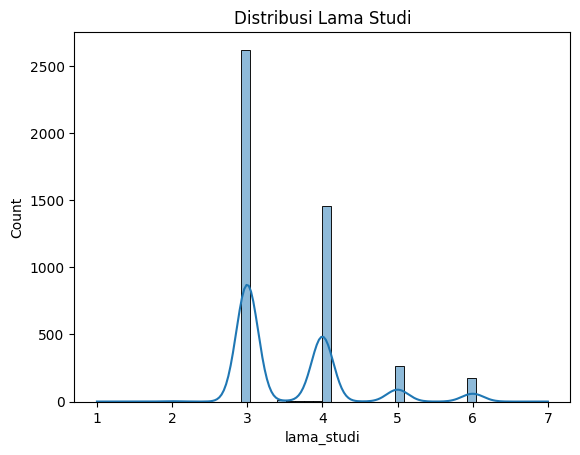

In [ ]:
# Visualisasi distribusi lama studi

sns.histplot(y, kde=True)
plt.title("Distribusi Lama Studi")
plt.show()

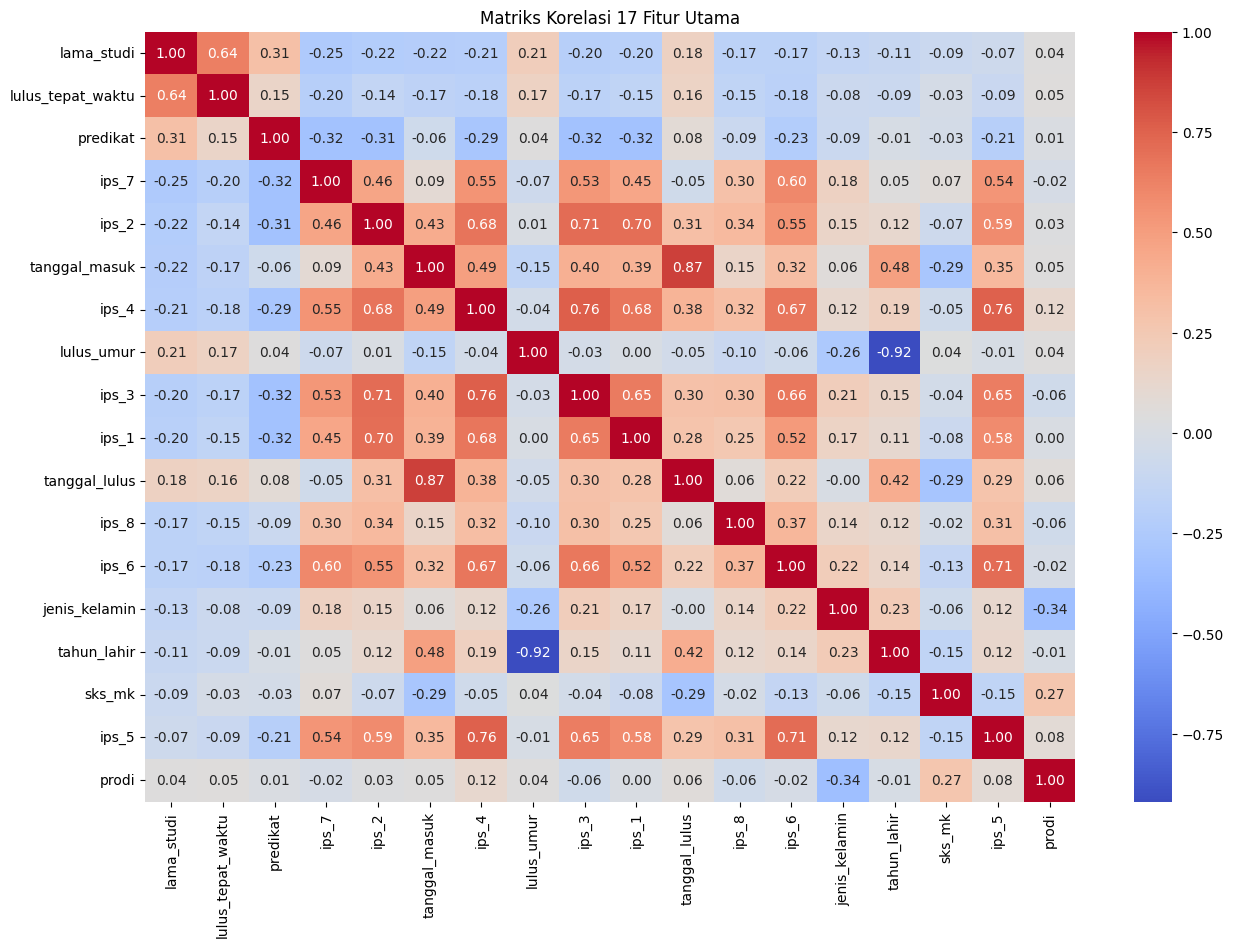

In [ ]:
top_features = df.corr()['lama_studi'].abs().sort_values(ascending=False).head(18).index
df_top = df[top_features]

plt.figure(figsize=(15, 10))
sns.heatmap(df_top.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi 17 Fitur Utama")
plt.show()

4. DATA SPLITTING

In [ ]:
from sklearn.model_selection import train_test_split

splits = {
    '70:30': 0.3,
    '80:20': 0.2,
    '90:10': 0.1
}

split_data = {}

for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    split_data[name] = (X_train, X_test, y_train, y_test)

print("Splitting selesai")

Splitting selesai


5. MODEL BUILDING (membangun model)

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

# =========================
# 1. SPLIT DATA
# =========================
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

results = []

for nama_split, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # --- Preprocessing for X_train and X_test ---
    # Make copies to avoid modifying original X_train/X_test
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    # Convert datetime columns to numerical Unix timestamps
    datetime_cols = X_train_processed.select_dtypes(include=['datetime64[ns]']).columns
    for col in datetime_cols:
        X_train_processed[col] = X_train_processed[col].astype(int) / 10**9
        X_test_processed[col] = X_test_processed[col].astype(int) / 10**9

    # Label Encoding for object (string) columns
    object_cols = X_train_processed.select_dtypes(include=['object']).columns
    for col in object_cols:
        le = LabelEncoder()
        # Fit LabelEncoder on the combined unique values from train and test for the column
        all_unique_labels = pd.Series(list(X_train_processed[col].astype(str).unique()) +
                                      list(X_test_processed[col].astype(str).unique())).unique()
        le.fit(all_unique_labels)
        X_train_processed[col] = le.transform(X_train_processed[col].astype(str))
        X_test_processed[col] = le.transform(X_test_processed[col].astype(str))
    # --- End Preprocessing ---

    # =========================
    # 2. MODEL DEFAULT (TANPA TUNING)
    # =========================
    models = {
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42)
    }

    for nama_model, model in models.items():

        # TRAIN
        model.fit(X_train_processed, y_train) # Use processed data

        # PREDIKSI
        y_pred = model.predict(X_test_processed) # Use processed data

        # =========================
        # 3. EVALUASI
        # =========================
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append({
            "Split": nama_split,
            "Model": nama_model,
            "R2": round(r2, 4),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })

# =========================
# 4. TAMPILKAN HASIL
# =========================
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="R2", ascending=False)

print("\nHASIL SEBELUM TUNING:")
print(df_results)


HASIL SEBELUM TUNING:
   Split              Model      R2     MAE    RMSE
6  90:10      Random Forest  0.9926  0.0090  0.0675
0  70:30      Random Forest  0.9881  0.0117  0.0843
8  90:10            XGBoost  0.9878  0.0114  0.0864
7  90:10  Gradient Boosting  0.9862  0.0337  0.0919
3  80:20      Random Forest  0.9825  0.0117  0.0999
2  70:30            XGBoost  0.9798  0.0138  0.1101
1  70:30  Gradient Boosting  0.9750  0.0361  0.1225
5  80:20            XGBoost  0.9716  0.0143  0.1272
4  80:20  Gradient Boosting  0.9598  0.0358  0.1513


6.HYPERPARAMETER TUNING

In [ ]:
# ==========================================
# HYPERPARAMETER TUNING
# Random Forest, Gradient Boosting, XGBoost
# ==========================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd # Import pandas for Series.unique() in LabelEncoder fix
from sklearn.preprocessing import LabelEncoder # Ensure LabelEncoder is available

# 1. Definisi parameter tuning
param_grids = {

    'Random Forest': {
        'n_estimators': [200, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'bootstrap': [True]
    },

    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    },

    'XGBoost': {
        'n_estimators': [300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
}

# List hasil
all_tuning_results = []

# Dictionary to store the best model objects for each split and algorithm
best_models_per_split_and_algo = {}

print("=== MEMULAI HYPERPARAMETER TUNING ===")

# 2. Loop tiap skenario split
for label, (X_train, X_test, y_train, y_test) in split_data.items():
    print(f"\n>> Skenario Split {label}")

    # Initialize for the current split
    best_models_per_split_and_algo[label] = {}

    # Make copies to process for tuning
    X_train_processed_tuning = X_train.copy()
    X_test_processed_tuning = X_test.copy()

    # Identify and convert datetime columns to numerical Unix timestamps
    datetime_cols = X_train_processed_tuning.select_dtypes(include=['datetime64[ns]']).columns
    for col in datetime_cols:
        X_train_processed_tuning[col] = X_train_processed_tuning[col].astype(int) / 10**9 # Convert to Unix timestamp
        X_test_processed_tuning[col] = X_test_processed_tuning[col].astype(int) / 10**9

    # Identify and convert other object columns (strings) using LabelEncoder
    object_cols = X_train_processed_tuning.select_dtypes(include=['object']).columns
    for col in object_cols:
        le = LabelEncoder()
        # Fit LabelEncoder on the combined unique values from train and test for the column
        all_unique_labels = pd.Series(list(X_train_processed_tuning[col].astype(str).unique()) + \
                                      list(X_test_processed_tuning[col].astype(str).unique())).unique()
        le.fit(all_unique_labels)

        # Transform both training and test data using the fitted encoder
        X_train_processed_tuning[col] = le.transform(X_train_processed_tuning[col].astype(str))
        X_test_processed_tuning[col] = le.transform(X_test_processed_tuning[col].astype(str))

    for model_name in param_grids:

        # Pilih model
        if model_name == 'Random Forest':
            base_model = RandomForestRegressor(random_state=42)

        elif model_name == 'Gradient Boosting':
            base_model = GradientBoostingRegressor(random_state=42)

        else:
            base_model = XGBRegressor(random_state=42, verbosity=0)

        # 3. Random Search
        tuning = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grids[model_name],
            n_iter=15,          # lebih banyak kombinasi → hasil lebih bagus
            cv=5,               # validasi lebih kuat
            scoring='r2',
            random_state=42,
            n_jobs=-1
        )

        # Training
        tuning.fit(X_train_processed_tuning, y_train)

        # Model terbaik
        best_model = tuning.best_estimator_

        # Store the best model object
        best_models_per_split_and_algo[label][model_name] = best_model

        # 4. Evaluasi
        y_pred = best_model.predict(X_test_processed_tuning)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        # Simpan hasil
        all_tuning_results.append({
            'Skenario Split': label,
            'Algoritma': model_name,
            'R2 Score': round(r2, 4),
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'Best Params': tuning.best_params_
        })

        print(f"   [Selesai] {model_name} | R2: {r2:.4f}")

=== MEMULAI HYPERPARAMETER TUNING ===

>> Skenario Split 70:30
   [Selesai] Random Forest | R2: 0.9881
   [Selesai] Gradient Boosting | R2: 0.9820
   [Selesai] XGBoost | R2: 0.9810

>> Skenario Split 80:20
   [Selesai] Random Forest | R2: 0.9830
   [Selesai] Gradient Boosting | R2: 0.9719
   [Selesai] XGBoost | R2: 0.9650

>> Skenario Split 90:10
   [Selesai] Random Forest | R2: 0.9924
   [Selesai] Gradient Boosting | R2: 0.9898
   [Selesai] XGBoost | R2: 0.9860


7. MODEL EVALUATION

In [ ]:
# ==========================================
# MODEL EVALUATION
# ==========================================
# Mengukur performa model menggunakan MAE, RMSE, dan R2

from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

for split_name, (X_train, X_test, y_train, y_test) in split_data.items():

    print(f"\nSplit {split_name}")

    # Make a copy of X_test for processing
    X_test_processed = X_test.copy()

    # Identify and convert datetime columns to numerical Unix timestamps
    datetime_cols = X_test_processed.select_dtypes(include=['datetime64[ns]']).columns
    for col in datetime_cols:
        X_test_processed[col] = X_test_processed[col].astype(int) / 10**9 # Convert to Unix timestamp

    # Identify and convert other object columns (strings) using LabelEncoder
    # Ensure LabelEncoder is fitted on combined unique values to handle unseen labels
    object_cols = X_test_processed.select_dtypes(include=['object']).columns
    for col in object_cols:
        le = LabelEncoder()
        # Fit LabelEncoder on the combined unique values from train and test for the column
        all_unique_labels = pd.Series(list(X_train[col].astype(str).unique()) + \
                                      list(X_test[col].astype(str).unique())).unique()
        le.fit(all_unique_labels)

        # Transform the test data using the fitted encoder
        X_test_processed[col] = le.transform(X_test_processed[col].astype(str))

    # Use the correctly populated dictionary from the tuning step
    for name, model in best_models_per_split_and_algo[split_name].items():

        pred = model.predict(X_test_processed)

        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)

        print(f"{name} | R2={r2:.4f}")

        results.append({
            'Split': split_name,
            'Model': name,
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse
        })



Split 70:30
Random Forest | R2=0.9881
Gradient Boosting | R2=0.9820
XGBoost | R2=0.9810

Split 80:20
Random Forest | R2=0.9830
Gradient Boosting | R2=0.9719
XGBoost | R2=0.9650

Split 90:10
Random Forest | R2=0.9924
Gradient Boosting | R2=0.9898
XGBoost | R2=0.9860


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Select the split for which to retrieve X_train and y_train
# Using the '70:30' split as an example, consistent with the best model found.
selected_split = '70:30'
X_train, _, y_train, _ = split_data[selected_split]

# Make a copy to avoid modifying the original split_data
X_train_processed = X_train.copy()

# Preprocessing steps (converting datetime and object columns) must be applied
# consistent with how the models were trained during hyperparameter tuning.

# Identify and convert datetime columns to numerical Unix timestamps
datetime_cols = X_train_processed.select_dtypes(include=['datetime64[ns]']).columns
for col in datetime_cols:
    X_train_processed[col] = X_train_processed[col].astype(int) / 10**9 # Convert to Unix timestamp

# Identify and convert other object columns (strings) using LabelEncoder
object_cols = X_train_processed.select_dtypes(include=['object']).columns
for col in object_cols:
    le = LabelEncoder()
    # Fit LabelEncoder on unique values from X_train for this example
    # In a real scenario, it's better to fit on combined train+test or a global vocabulary
    # as done in the tuning step for consistent encoding.
    X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))

# Now, fit the rf model with the preprocessed data
rf.fit(X_train_processed, y_train)
print(f"RandomForestRegressor fitted successfully using {selected_split} split data.")

RandomForestRegressor fitted successfully using 70:30 split data.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# ======================
# MISAL DATA SUDAH ADA
# ======================
# X = fitur
# y = target

splits = [0.7, 0.8, 0.9]

for split in splits:
    print(f"\n===== SPLIT {int(split*100)}:{int((1-split)*100)} ====")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=(1 - split), random_state=42
    )

    # Make copies for preprocessing to avoid modifying original X and X_train/X_test from split
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    # Preprocessing steps (must match previous preprocessing logic)
    # 1. Convert datetime columns to numerical Unix timestamps
    datetime_cols = X_train_processed.select_dtypes(include=['datetime64[ns]']).columns
    for col in datetime_cols:
        X_train_processed[col] = X_train_processed[col].astype(int) / 10**9
        X_test_processed[col] = X_test_processed[col].astype(int) / 10**9

    # 2. Label Encoding for object (string) columns
    object_cols = X_train_processed.select_dtypes(include=['object']).columns
    for col in object_cols:
        le = LabelEncoder()
        # Fit LabelEncoder on the combined unique values from train and test for the column
        all_unique_labels = pd.Series(list(X_train_processed[col].astype(str).unique()) + \
                                      list(X_test_processed[col].astype(str).unique())).unique()
        le.fit(all_unique_labels)
        X_train_processed[col] = le.transform(X_train_processed[col].astype(str))
        X_test_processed[col] = le.transform(X_test_processed[col].astype(str))

    # Model
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train_processed, y_train)

    # Prediksi
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    # ======================
    # TRAINING
    # ======================
    print("=== TRAINING ===")
    print("R2  :", round(r2_score(y_train, y_train_pred), 4))
    print("MAE :", round(mean_absolute_error(y_train, y_train_pred), 4))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 4))

    # ======================
    # TESTING
    # ======================
    print("=== TESTING ===")
    print("R2  :", round(r2_score(y_test, y_test_pred), 4))
    print("MAE :", round(mean_absolute_error(y_test, y_test_pred), 4))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 4))

    # ======================
    # CEK OVERFITTING
    # ======================
    selisih = r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)

    print("Selisih R2:", round(selisih, 4))

    if selisih > 0.05:
        print("⚠️ Overfitting")
    else:
        print("✅ Model Stabil")


===== SPLIT 70:30 ====
=== TRAINING ===
R2  : 0.9983
MAE : 0.0055
RMSE: 0.0323
=== TESTING ===
R2  : 0.9881
MAE : 0.0117
RMSE: 0.0843
Selisih R2: 0.0101
✅ Model Stabil

===== SPLIT 80:19 ====
=== TRAINING ===
R2  : 0.9983
MAE : 0.0048
RMSE: 0.0324
=== TESTING ===
R2  : 0.9825
MAE : 0.0117
RMSE: 0.0999
Selisih R2: 0.0158
✅ Model Stabil

===== SPLIT 90:9 ====
=== TRAINING ===
R2  : 0.9982
MAE : 0.0044
RMSE: 0.0325
=== TESTING ===
R2  : 0.9926
MAE : 0.009
RMSE: 0.0675
Selisih R2: 0.0057
✅ Model Stabil


8. MODEL COMPARISON

In [ ]:
df_comparison = pd.DataFrame(all_tuning_results)

print("\n" + "="*50)
print("HASIL AKHIR PERBANDINGAN MODEL (TUNED)")
print("="*50)
# Menampilkan tabel perbandingan yang urut berdasarkan R2 Score terbaik
print(df_comparison.sort_values(by=['R2 Score'], ascending=False).to_string(index=False))


HASIL AKHIR PERBANDINGAN MODEL (TUNED)
Skenario Split         Algoritma  R2 Score    MAE   RMSE                                                                                                Best Params
         90:10     Random Forest    0.9924 0.0108 0.0682 {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': True}
         90:10 Gradient Boosting    0.9898 0.0147 0.0790                              {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
         70:30     Random Forest    0.9881 0.0115 0.0843   {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}
         90:10           XGBoost    0.9860 0.0223 0.0925     {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
         80:20     Random Forest    0.9830 0.0119 0.0985   {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth':

In [ ]:
# 6. Menyimpan model terbaik dari seluruh skenario untuk kebutuhan Deployment
# (Misal: Kita ambil baris pertama setelah di-sort)
best_overall_row = df_comparison.sort_values(by='R2 Score', ascending=False).iloc[0]
print(f"\nModel Terbaik Secara Keseluruhan: {best_overall_row['Algoritma']} pada split {best_overall_row['Skenario Split']}")


Model Terbaik Secara Keseluruhan: Random Forest pada split 90:10


In [ ]:
import joblib

# 1. Mencari model dengan R2 Score tertinggi dari hasil tuning
# all_tuning_results adalah list yang berisi hasil dari tahap sebelumnya
best_entry = max(all_tuning_results, key=lambda x: x['R2 Score'])

print(f"Model Terbaik ditemukan pada Skenario: {best_entry['Skenario Split']}")
print(f"Algoritma: {best_entry['Algoritma']}")
print(f"R2 Score: {best_entry['R2 Score']}")

# 2. Ambil objek model terbaiknya
# Catatan: Pastikan variabel 'best_model' di dalam loop tuning terakhir
# adalah model yang sesuai dengan 'best_entry' ini.
# Jika kamu menjalankan kode sebelumnya, model terbaik biasanya disimpan di variabel 'best_model'.
final_model = best_model

Model Terbaik ditemukan pada Skenario: 90:10
Algoritma: Random Forest
R2 Score: 0.9924


INFERENCE (Data Baru)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# =========================
# 1. UPLOAD FILE
# =========================
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Baca file
if file_name.endswith('.csv'):
    data_baru = pd.read_csv(file_name)
elif file_name.endswith('.xlsx'):
    data_baru = pd.read_excel(file_name)
else:
    raise ValueError("Format file tidak didukung")

print("Data sebelum preprocessing:")
print(data_baru.head())


# =========================
# 2. HAPUS KOLOM TARGET (JIKA ADA)
# =========================
target_col = 'lama_studi'  # ganti kalau nama target kamu beda

if target_col in data_baru.columns:
    data_baru = data_baru.drop(columns=[target_col])
    print(f"\nKolom '{target_col}' dihapus karena itu target.")


# =========================
# 3. SAMAKAN KOLOM DENGAN X_train
# =========================
# Tambahkan kolom yang kurang
for col in X_train.columns:
    if col not in data_baru.columns:
        data_baru[col] = 0  # isi default

# Urutkan kolom agar sama
data_baru = data_baru[X_train.columns]


# =========================
# 4. PREPROCESSING
# =========================

# --- datetime ke timestamp ---
datetime_cols = data_baru.select_dtypes(include=['datetime64[ns]']).columns
for col in datetime_cols:
    data_baru[col] = data_baru[col].astype(int) / 10**9


# --- encoding kategori ---
object_cols = data_baru.select_dtypes(include=['object']).columns

for col in object_cols:
    le = LabelEncoder()

    all_unique_labels = pd.Series(
        list(X_train[col].astype(str).unique()) +
        list(data_baru[col].astype(str).unique())
    ).unique()

    le.fit(all_unique_labels)
    data_baru[col] = le.transform(data_baru[col].astype(str))


# =========================
# 5. LOAD MODEL
# =========================
model = rf  # pastikan model sudah dilatih


# =========================
# 6. PREDIKSI
# =========================
hasil = model.predict(data_baru)

data_baru['hasil_prediksi'] = hasil

print("\nHasil Prediksi:")
print(data_baru)


# =========================
# 7. DOWNLOAD HASIL
# =========================
data_baru.to_excel("hasil_prediksi.xlsx", index=False)
files.download("hasil_prediksi.xlsx")

Saving mhs_lulusan_clean.csv.xlsx to mhs_lulusan_clean.csv (2).xlsx
Data sebelum preprocessing:
             prodi predikat tanggal_lulus tanggal_masuk jenis_kelamin  \
0  Teknik Industri   Pujian    2019-08-31    2015-09-06     Laki-laki   
1  Teknik Industri   Pujian    2019-08-31    2015-09-06     Perempuan   
2  Teknik Industri   Pujian    2019-08-31    2015-09-06     Laki-laki   
3  Teknik Industri   Pujian    2019-08-31    2015-09-06     Laki-laki   
4  Teknik Industri   Pujian    2019-08-31    2015-09-06     Laki-laki   

   tahun_lahir status_pegawai     ips_1     ips_2     ips_3    ips_4  \
0         1994        Bekerja  3.223333  3.431429  2.947778  2.90875   
1         1996        Bekerja  3.305556  3.430000  3.111111  3.34375   
2         1984        Bekerja  3.225556  3.324286  2.946667  3.22000   
3         1996        Bekerja  3.334444  3.288571  3.224444  3.44000   
4         1994        Bekerja  3.142222  3.394286  3.000000  3.25000   

      ips_5    ips_6     ips_7  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

BOXPLOT

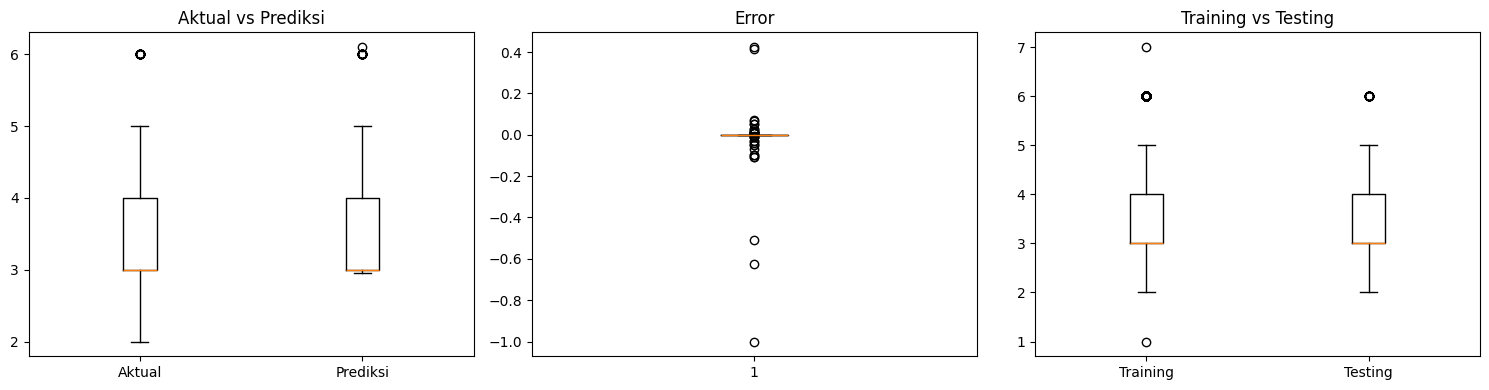

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ======================
# HITUNG ERROR
# ======================
error = y_test - y_test_pred

# ======================
# BUAT 3 BOXPLOT SEKALIGUS
# ======================
plt.figure(figsize=(15, 4))

# 1. Aktual vs Prediksi
plt.subplot(1, 3, 1)
plt.boxplot([y_test, y_test_pred])
plt.xticks([1, 2], ['Aktual', 'Prediksi'])
plt.title("Aktual vs Prediksi")

# 2. Error
plt.subplot(1, 3, 2)
plt.boxplot(error)
plt.title("Error")

# 3. Training vs Testing
plt.subplot(1, 3, 3)
plt.boxplot([y_train, y_test])
plt.xticks([1, 2], ['Training', 'Testing'])
plt.title("Training vs Testing")

plt.tight_layout()
plt.show()